In [35]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import mannwhitneyu

# Centrosome analysis

Channel 1 - centrin?
Channel 2 - gamma tubulin?

## Parameters

In [2]:
DIR = "/mnt/c/users/helen/Desktop/test"

## Data loading

In [3]:
from utils import load_data, data_subset

In [4]:
df = load_data(DIR)

In [5]:
df

,,Image,Cell,Channel number,ROI,File,Path
0,1,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04,1,1,0424-0565,results_2_hct116_wt_pcdna_vacio__pcnt-gamma_tu...,/mnt/c/users/helen/Desktop/test/results_2_hct1...
1,2,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04,1,2,0309-0430,results_2_hct116_wt_pcdna_vacio__pcnt-gamma_tu...,/mnt/c/users/helen/Desktop/test/results_2_hct1...
2,3,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04,1,2,0307-0439,results_2_hct116_wt_pcdna_vacio__pcnt-gamma_tu...,/mnt/c/users/helen/Desktop/test/results_2_hct1...
3,4,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04,2,1,0481-0492,results_2_hct116_wt_pcdna_vacio__pcnt-gamma_tu...,/mnt/c/users/helen/Desktop/test/results_2_hct1...
4,5,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04,2,1,0492-0493,results_2_hct116_wt_pcdna_vacio__pcnt-gamma_tu...,/mnt/c/users/helen/Desktop/test/results_2_hct1...
5,6,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04,2,2,0482-0430,results_2_hct116_wt_pcdna_vacio__pcnt-gamma_tu...,/mnt/c/users/helen/Desktop/test/results_2_hct1...
6,1,hct116_4_pcdna_vacio_+_satr2__pcnt-gamma_tub-11,1,1,0465-0213,results_hct116_4_pcdna_vacio_+_satr2__pcnt-gam...,/mnt/c/users/helen/Desktop/test/results_hct116...
7,2,hct116_4_pcdna_vacio_+_satr2__pcnt-gamma_tub-11,1,2,0456-0232,results_hct116_4_pcdna_vacio_+_satr2__pcnt-gam...,/mnt/c/users/helen/Desktop/test/results_hct116...


In [6]:
ch1 = data_subset(df, channel = 1)
ch2 = data_subset(df, channel = 2)

In [7]:
ch1

,,Image,Cell,Channel number,ROI,File,Path
0,1,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04,1,1,0424-0565,results_2_hct116_wt_pcdna_vacio__pcnt-gamma_tu...,/mnt/c/users/helen/Desktop/test/results_2_hct1...
3,4,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04,2,1,0481-0492,results_2_hct116_wt_pcdna_vacio__pcnt-gamma_tu...,/mnt/c/users/helen/Desktop/test/results_2_hct1...
4,5,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04,2,1,0492-0493,results_2_hct116_wt_pcdna_vacio__pcnt-gamma_tu...,/mnt/c/users/helen/Desktop/test/results_2_hct1...
6,1,hct116_4_pcdna_vacio_+_satr2__pcnt-gamma_tub-11,1,1,0465-0213,results_hct116_4_pcdna_vacio_+_satr2__pcnt-gam...,/mnt/c/users/helen/Desktop/test/results_hct116...


## Data processing

In [29]:
roi_counts= ch2.groupby(['Image','Cell'])['ROI'].count()

In [30]:
roi_counts

Image                                            Cell
2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04       1       2
                                                 2       1
hct116_4_pcdna_vacio_+_satr2__pcnt-gamma_tub-11  1       1
Name: ROI, dtype: int64

## Graphs

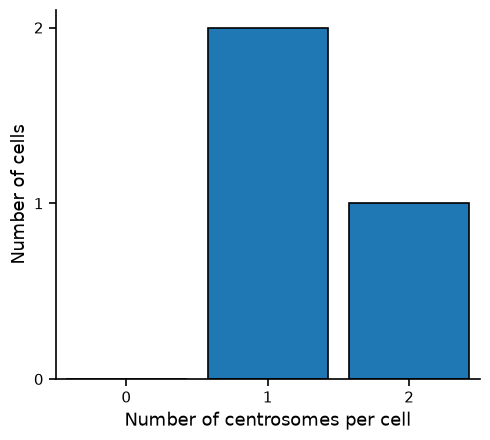

In [36]:
fig, ax = plt.subplots(figsize=(5, 4.5))

max_count = int(roi_counts.max())

# Bins centered on integers
bins = np.arange(-0.5, max_count + 1.5, 1)

ax.hist(
    roi_counts,
    bins=bins,
    edgecolor="black",
    linewidth=1.2,
    rwidth=0.85
)

# Labels
ax.set_xlabel(
    "Number of centrosomes per cell",
    fontsize=13
)

ax.set_ylabel(
    "Number of cells",
    fontsize=13
)

# Integer ticks
ax.set_xticks(range(0, max_count + 1))
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

# Tick appearance
ax.tick_params(
    axis="both",
    labelsize=11,
    width=1.2,
    length=5
)

# Cleaner frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

# Start axes at zero
ax.set_xlim(-0.5, max_count + 0.5)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()